# Trabalho Final de IA
## Comparação de Modelos Supervisionados em Dois Datasets

**Datasets escolhidos:**
- **Estimation of Obesity Levels** → Naive Bayes + Árvore de Decisão
- **Students Dropout and Academic Success** → Regressão Logística + Árvore de Decisão

**Modelos distintos utilizados:** Naive Bayes, Regressão Logística, Árvore de Decisão.

**Grupo:** *Heitor Costa Grivicich, Pedro Henrique Schneider Conzatti, Rafael da Fontoura Cardoso*

---

### Estrutura do notebook
1. Setup e bibliotecas
2. Dataset 1 — Obesity Levels (EDA, pré-processamento, modelos, hiperparâmetros)
3. Dataset 2 — Students Dropout (EDA, pré-processamento, modelos, hiperparâmetros)
4. Comparação entre os 4 modelos
5. Discussão crítica (overfitting/underfitting, generalização, interpretabilidade)
6. Conclusão

---
#### Observação
Código gerado com auxílio de IA (Claude)

## 1. Setup e Bibliotecas

In [1]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


---
## 2. Dataset 1 — Estimation of Obesity Levels

### 2.1 Descrição do dataset

Este dataset reúne dados de hábitos alimentares e condição física de indivíduos do México, Peru e
Colômbia, usados para estimar o nível de obesidade de cada pessoa com base em atributos pessoais e comportamentais. Possui **2111 registros** e **17 colunas** (16
atributos + 1 variável-alvo), sem valores nulos. As classes estão bem balaceadas

**Variável-alvo (`NObeyesdad`)**: 7 classes — Insufficient_Weight, Normal_Weight, Overweight_Level_I,
Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III — relativamente **balanceadas**
(entre 272 e 351 registros por classe).

**Atributos:** combinação de variáveis numéricas (idade, altura, peso, frequência de consumo de
vegetais, número de refeições, consumo de água, atividade física, tempo de uso de telas) e categóricas
(gênero, histórico familiar de sobrepeso, consumo de alimentos calóricos, tabagismo, consumo de
álcool, meio de transporte, etc.).

In [2]:
obesity = pd.read_csv('ObesityDataSet.csv')

print("Shape:", obesity.shape)
print("\nValores nulos por coluna:")
print(obesity.isnull().sum().sum(), "valores nulos no total")
obesity.head()

Shape: (2111, 17)

Valores nulos por coluna:
0 valores nulos no total


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
obesity.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

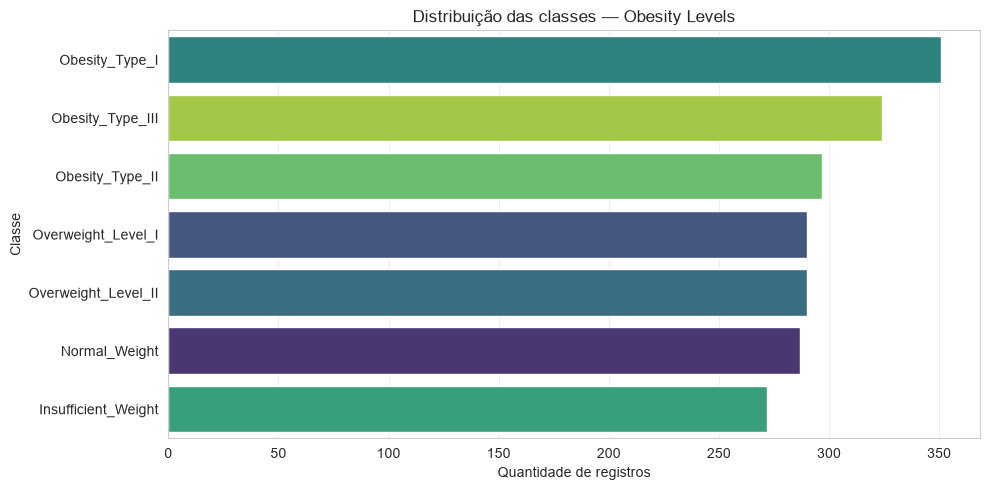

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


In [38]:
# Distribuição da variável-alvo
plt.figure(figsize=(10, 5))
order = obesity['NObeyesdad'].value_counts().index
sns.countplot(data=obesity, y='NObeyesdad', hue='NObeyesdad', legend=False, order=order, palette='viridis')
plt.title('Distribuição das classes — Obesity Levels')
plt.xlabel('Quantidade de registros')
plt.ylabel('Classe')
plt.tight_layout()
plt.show()

print(obesity['NObeyesdad'].value_counts())

In [5]:
# Estatísticas descritivas das variáveis numéricas
num_cols_ob = obesity.select_dtypes(include=[np.number]).columns.tolist()
obesity[num_cols_ob].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00
FCVC,2111.0,2.419043,0.533927,1.00,2.000000,2.385502,3.000000,3.00
NCP,2111.0,2.685628,0.778039,1.00,2.658738,3.000000,3.000000,4.00
CH2O,2111.0,2.008011,0.612953,1.00,1.584812,2.000000,2.477420,3.00
FAF,2111.0,1.010298,0.850592,0.00,0.124505,1.000000,1.666678,3.00
TUE,2111.0,0.657866,0.608927,0.00,0.000000,0.625350,1.000000,2.00


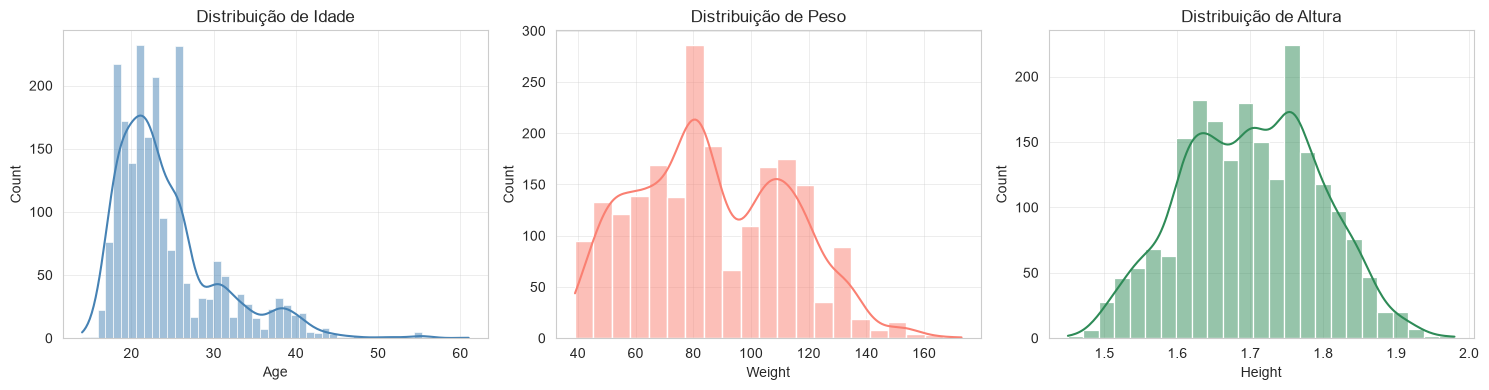

In [6]:
# Distribuição de algumas variáveis numéricas-chave
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(obesity['Age'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição de Idade')
sns.histplot(obesity['Weight'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribuição de Peso')
sns.histplot(obesity['Height'], kde=True, ax=axes[2], color='seagreen')
axes[2].set_title('Distribuição de Altura')
plt.tight_layout()
plt.show()

A partir dos gráficos e tabelas apresentados, conseguimos observar que as classes estão relativamente balanceadas, fazendo com que que o treinamento do modelo seja sem viés de classe. Também temos a análise exploratória em que são visualizadas a distribuição e a tendência dos dados mais relevantes do conjunto.

### 2.2 Pré-processamento

- Variáveis categóricas codificadas com `LabelEncoder` (ferramenta do SciKit-Learn que converte dados categóricos em valores numéricos inteiros).
- Variáveis numéricas padronizadas com `StandardScaler` (padroniza valores numéricos; necessário para Naive Bayes; a Árvore de Decisão não exige escalonamento, mas mantemos os dados originais para ela, já que árvores são invariantes a transformações monotônicas, isto é, sua decisão não se baseia na escala da variável).
- Divisão treino/teste: 80% / 20%, estratificada pela variável-alvo para preservar a proporção das
  classes.

In [39]:
target_col = 'NObeyesdad'
X_ob = obesity.drop(columns=[target_col])
y_ob = obesity[target_col]

cat_cols_ob = X_ob.select_dtypes(include='str').columns.tolist()
num_cols_ob = X_ob.select_dtypes(exclude='object').columns.tolist()
print("Colunas categóricas:", cat_cols_ob)
print("Colunas numéricas:", num_cols_ob)

# Encoding das categóricas
X_ob_enc = X_ob.copy()
for c in cat_cols_ob:
    le = LabelEncoder()
    X_ob_enc[c] = le.fit_transform(X_ob_enc[c])

# Encoding do target
y_ob_le = LabelEncoder()
y_ob_enc = y_ob_le.fit_transform(y_ob)
print("\nClasses (codificadas):", dict(enumerate(y_ob_le.classes_)))

Colunas categóricas: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
Colunas numéricas: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

Classes (codificadas): {0: 'Insufficient_Weight', 1: 'Normal_Weight', 2: 'Obesity_Type_I', 3: 'Obesity_Type_II', 4: 'Obesity_Type_III', 5: 'Overweight_Level_I', 6: 'Overweight_Level_II'}


In [8]:
# Split treino/teste estratificado
X_ob_train, X_ob_test, y_ob_train, y_ob_test = train_test_split(
    X_ob_enc, y_ob_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_ob_enc
)

# Padronização
scaler_ob = StandardScaler()
X_ob_train_s = scaler_ob.fit_transform(X_ob_train)
X_ob_test_s = scaler_ob.transform(X_ob_test)

print("Treino:", X_ob_train.shape, " Teste:", X_ob_test.shape)

Treino: (1688, 16)  Teste: (423, 16)


### 2.3 Modelo 1 — Naive Bayes

Naive Bayes (Gaussian) assume independência condicional entre os atributos dado a classe e que cada
atributo segue uma distribuição normal. É um modelo simples, conputacionalmente eficiente e funciona bem como baseline,
supondo a independência entre as variáveis dos dados. Uma de suas limitações é de que, no mundo real, as variáveis raramente são totalmente independentes. No caso deste dataset, já podemos, antes de qualquer teste com o modelo, concluir que peso e altura estão relacionados.

**Hiperparâmetro testado:** `var_smoothing` — controla a quantidade de variância adicionada às
distribuições para estabilizar o cálculo (evita divisão por zero em variâncias muito pequenas).

In [9]:
resultados_nb = []

for vs in [1e-9, 1e-5, 1e-2]:
    nb = GaussianNB(var_smoothing=vs)
    nb.fit(X_ob_train_s, y_ob_train)

    pred_train = nb.predict(X_ob_train_s)
    pred_test = nb.predict(X_ob_test_s)

    resultados_nb.append({
        'var_smoothing': vs,
        'acc_train': accuracy_score(y_ob_train, pred_train),
        'acc_test': accuracy_score(y_ob_test, pred_test),
        'f1_macro_test': f1_score(y_ob_test, pred_test, average='macro'),
        'precision_macro_test': precision_score(y_ob_test, pred_test, average='macro'),
        'recall_macro_test': recall_score(y_ob_test, pred_test, average='macro'),
    })

df_nb = pd.DataFrame(resultados_nb)
df_nb

,var_smoothing,acc_train,acc_test,f1_macro_test,precision_macro_test,recall_macro_test
0,1.000000e-09,0.588863,0.598109,0.570748,0.651177,0.594506
1,1.000000e-05,0.590640,0.605201,0.579492,0.656280,0.600629
2,1.000000e-02,0.607227,0.612293,0.588770,0.660438,0.606411


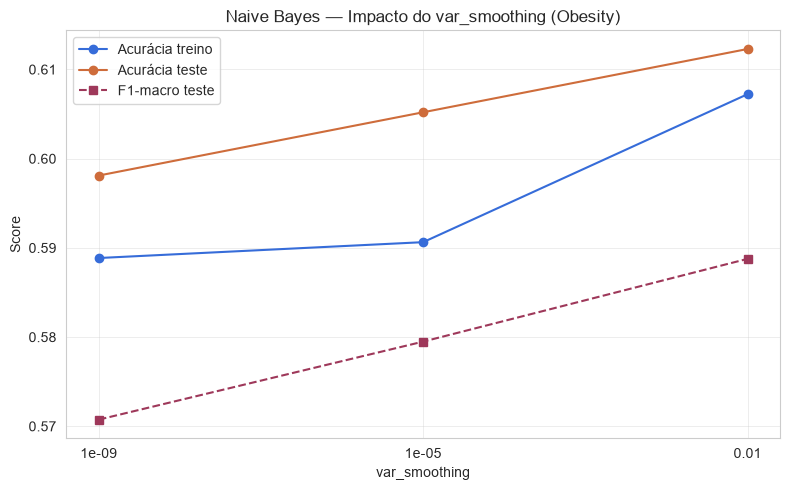

In [10]:
# Gráfico do impacto do var_smoothing
plt.figure(figsize=(8, 5))
plt.plot(df_nb['var_smoothing'].astype(str), df_nb['acc_train'], marker='o', label='Acurácia treino')
plt.plot(df_nb['var_smoothing'].astype(str), df_nb['acc_test'], marker='o', label='Acurácia teste')
plt.plot(df_nb['var_smoothing'].astype(str), df_nb['f1_macro_test'], marker='s', label='F1-macro teste', linestyle='--')
plt.xlabel('var_smoothing')
plt.ylabel('Score')
plt.title('Naive Bayes — Impacto do var_smoothing (Obesity)')
plt.legend()
plt.tight_layout()
plt.show()

Estes gráficos nos mostram que ao aumentar a suavização (var_soothing) o desempenho melhorou levemente. Com isso, pode-se inferir que o dataset possui variâncias baixas em alguns atributos, ocorrendo estabilização de estimativas de distribuição com a suavização adicional. Conclui-se que o modelo não é muito sensível ao hiperparâmetro analisado e comprova que o modelo possui suas limitações na questão de correlação entre atributos.

In [11]:
# Melhor configuração de Naive Bayes -> usada nas comparações finais
melhor_vs = df_nb.loc[df_nb['f1_macro_test'].idxmax(), 'var_smoothing']
nb_final = GaussianNB(var_smoothing=melhor_vs)
nb_final.fit(X_ob_train_s, y_ob_train)
pred_nb_final = nb_final.predict(X_ob_test_s)

print(f"Melhor var_smoothing: {melhor_vs}")
print(classification_report(y_ob_test, pred_nb_final, target_names=y_ob_le.classes_))

Melhor var_smoothing: 0.01
                     precision    recall  f1-score   support

Insufficient_Weight       0.69      0.83      0.76        54
      Normal_Weight       0.67      0.41      0.51        58
     Obesity_Type_I       0.34      0.61      0.44        70
    Obesity_Type_II       0.63      0.93      0.75        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.63      0.29      0.40        58
Overweight_Level_II       0.67      0.17      0.27        58

           accuracy                           0.61       423
          macro avg       0.66      0.61      0.59       423
       weighted avg       0.66      0.61      0.59       423



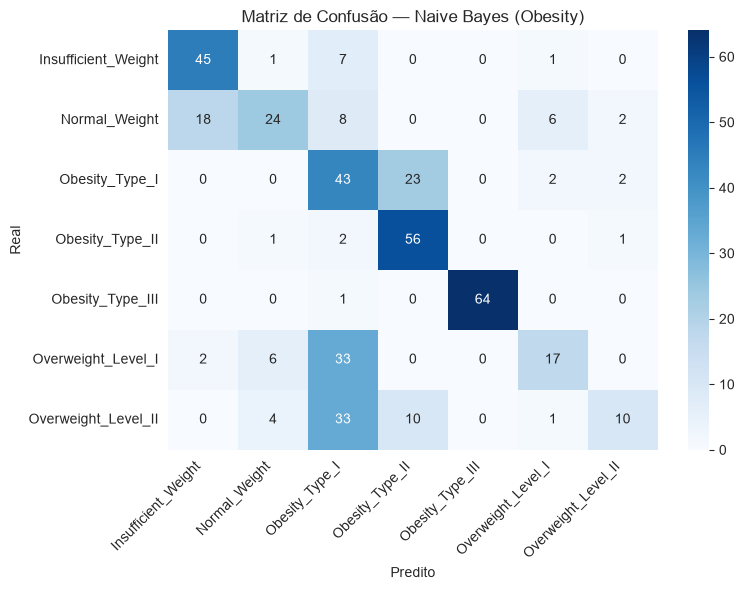

In [12]:
# Matriz de confusão - Naive Bayes
cm_nb = confusion_matrix(y_ob_test, pred_nb_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=y_ob_le.classes_, yticklabels=y_ob_le.classes_)
plt.title('Matriz de Confusão — Naive Bayes (Obesity)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Ao realizar a análise por classe, percebe-se a desigualdade de desempenho. Para Obesity_Type_III o F1 atinge 99%, mas em Overweight_Level_I e II, o F1 está em 40% e 27%, respectivamente. Isso ocorre, porque para os casos mais extremos de obesidade, os atributos são muito distintos, facilitando a predição do modelo, enquanto os casos citados de sobrepeso possuem características sobrepostas com as classes vizinhas, confundindo o modelo. Essas erros podem ser bem observados no matriz de confusão, mostrando um grande número de erros em Obesity_Type_I, visto que é uma das classes com valores menos extremos.

### 2.4 Modelo 2 — Árvore de Decisão

Árvores de decisão particionam o espaço de atributos por meio de regras sequenciais. São interpretáveis
(é possível visualizar as regras de decisão), capturam relações não-lineares e interação entre as variáveis sem assumir independêcia, mas são propensas a
overfitting quando crescem sem restrição.

**Hiperparâmetro testado:** `max_depth` — profundidade máxima da árvore, controla diretamente a
complexidade do modelo. Uma profundidade baixa resulta em um modelo muito simples, podendo causar underfitting, enquanto uma profundidade sem limites pode causar overvitting, uma vez que permite que o modelo memorize todos os dados de treino.

In [40]:
resultados_dt_ob = []

for depth in [3, 7, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    dt.fit(X_ob_train, y_ob_train)

    pred_train = dt.predict(X_ob_train)
    pred_test = dt.predict(X_ob_test)

    resultados_dt_ob.append({
        'max_depth': depth if depth is not None else 'None (sem limite)',
        'acc_train': accuracy_score(y_ob_train, pred_train),
        'acc_test': accuracy_score(y_ob_test, pred_test),
        'f1_macro_test': f1_score(y_ob_test, pred_test, average='macro'),
        'precision_macro_test': precision_score(y_ob_test, pred_test, average='macro', zero_division=0),
        'recall_macro_test': recall_score(y_ob_test, pred_test, average='macro'),
    })

df_dt_ob = pd.DataFrame(resultados_dt_ob)
df_dt_ob

,max_depth,acc_train,acc_test,f1_macro_test,precision_macro_test,recall_macro_test
0,3,0.648697,0.664303,0.615892,0.611482,0.650891
1,7,0.930095,0.862884,0.860714,0.867187,0.857859
2,None (sem limite),1.000000,0.917258,0.916261,0.918963,0.915057


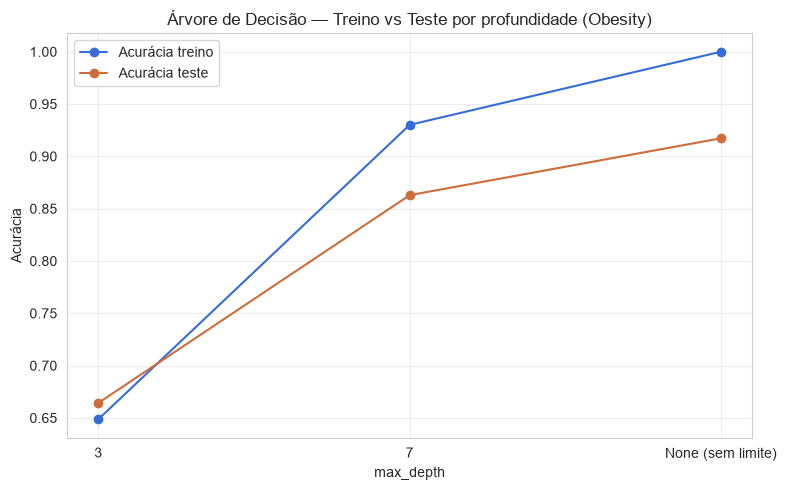

Observação: quanto maior a diferença entre acurácia de treino e teste, maior o overfitting.


In [14]:
# Gráfico: acurácia treino vs teste por profundidade (evidencia overfitting)
labels = [str(d) for d in df_dt_ob['max_depth']]
plt.figure(figsize=(8, 5))
plt.plot(labels, df_dt_ob['acc_train'], marker='o', label='Acurácia treino')
plt.plot(labels, df_dt_ob['acc_test'], marker='o', label='Acurácia teste')
plt.xlabel('max_depth')
plt.ylabel('Acurácia')
plt.title('Árvore de Decisão — Treino vs Teste por profundidade (Obesity)')
plt.legend()
plt.tight_layout()
plt.show()

print("Observação: quanto maior a diferença entre acurácia de treino e teste, maior o overfitting.")

Nestes gráficos ficou evidente a transição entre underfitting, equilíbrio e overfitting. Com max_depth=3, poercebe-se que a árvore erra bastante no treino e no teste, enquanto que, com max_depth=7, tem-se um pequeno overvitting, mas o desempenho no teste é muito superior ao valor anterior. A árvore sem limite de profundidade atinge 100% de acurácia no treino e 91,73% no teste, apresentando overfitting mais intenso que na profindidade 7. Com isso, pode-se concluir que, dos valores testados, o max_depth=7 é o que apresenta melhor equilíbrio entre acurácia de treino e de teste.

In [15]:
# Melhor configuração de Árvore -> usada nas comparações finais
melhor_depth = 7  # escolhido por equilibrar acc_test e generalização
dt_final_ob = DecisionTreeClassifier(max_depth=melhor_depth, random_state=RANDOM_STATE)
dt_final_ob.fit(X_ob_train, y_ob_train)
pred_dt_final_ob = dt_final_ob.predict(X_ob_test)

print(classification_report(y_ob_test, pred_dt_final_ob, target_names=y_ob_le.classes_))

                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.81      0.89        54
      Normal_Weight       0.79      0.76      0.77        58
     Obesity_Type_I       0.81      0.93      0.87        70
    Obesity_Type_II       0.97      0.97      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.74      0.79      0.77        58
Overweight_Level_II       0.79      0.76      0.77        58

           accuracy                           0.86       423
          macro avg       0.87      0.86      0.86       423
       weighted avg       0.87      0.86      0.86       423



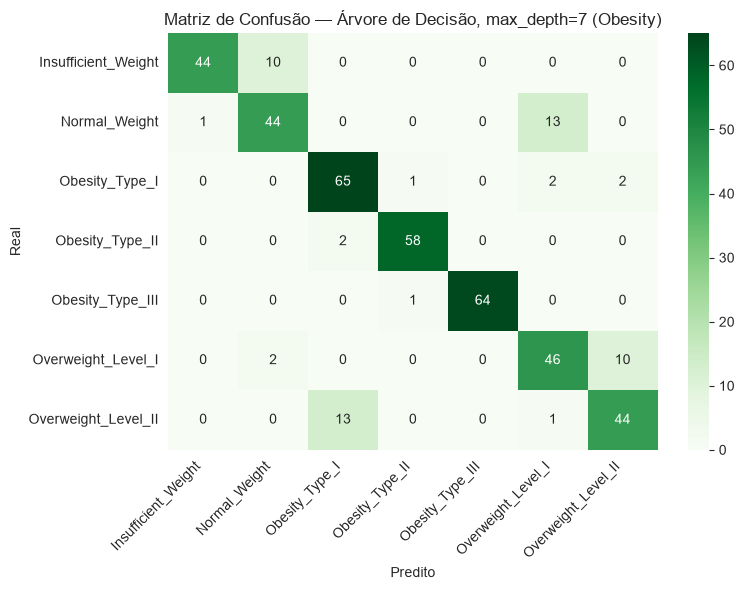

In [16]:
# Matriz de confusão - Árvore de Decisão
cm_dt_ob = confusion_matrix(y_ob_test, pred_dt_final_ob)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt_ob, annot=True, fmt='d', cmap='Greens',
            xticklabels=y_ob_le.classes_, yticklabels=y_ob_le.classes_)
plt.title(f'Matriz de Confusão — Árvore de Decisão, max_depth={melhor_depth} (Obesity)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Com as tabelas de resultados por classe e com a matriz de decisão, é possível observar a melhora em relação ao Naive Bayes. As classes mais problemáticas em relação ao F1 no modelo de Naive Bayes, que eram as de sobrepeso (pontuações de 27% e 40%), subiram para 77%. Isso mostra que essas classes têm fronteiras não-lineares que um modelo probabilístico simples não consegue identificar, mas que a árvore, por meio de regras de partição, consegue.

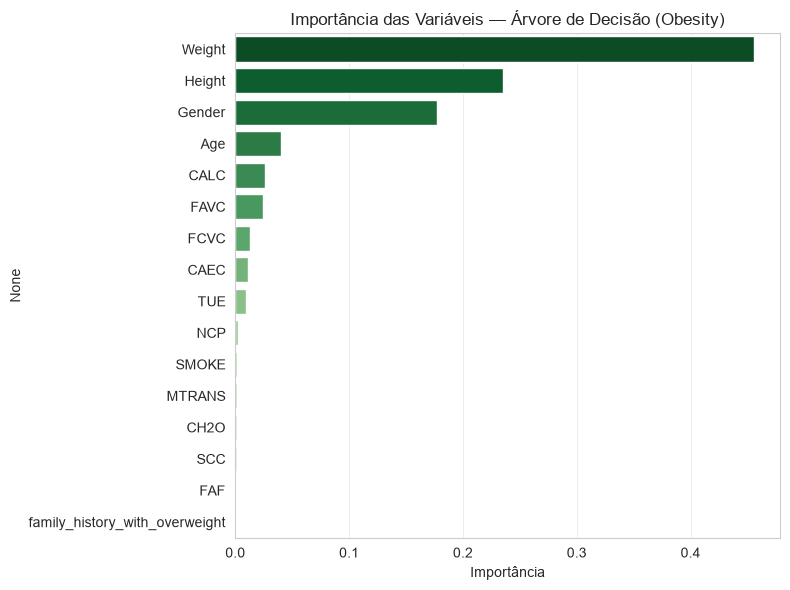

Weight                            0.455730
Height                            0.235104
Gender                            0.177098
Age                               0.040522
CALC                              0.025656
FAVC                              0.024404
FCVC                              0.013277
CAEC                              0.010767
TUE                               0.009646
NCP                               0.002100
SMOKE                             0.001519
MTRANS                            0.001506
CH2O                              0.001293
SCC                               0.001241
FAF                               0.000136
family_history_with_overweight    0.000000
dtype: float64

In [41]:
# Importância das variáveis (interpretabilidade)
importancias_ob = pd.Series(dt_final_ob.feature_importances_, index=X_ob_enc.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importancias_ob.values, y=importancias_ob.index, hue=importancias_ob.index, palette='Greens_r', legend=False)
plt.title('Importância das Variáveis — Árvore de Decisão (Obesity)')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

importancias_ob

O gráfico de importância das variáveis revela que o Peso (45,6%) e a Altura (23,5%) concentram 70% do poder preditivo da árvore. Isso ocorre, pois o nível de obesidade é definido pelo Índice de Massa corporal que utiliza essas duas variáveis na equação. O Gênero aparece em terceiro com 17,7%, possivelmente pela diferença de distribuição de peso e altura entre homens e mulheres.

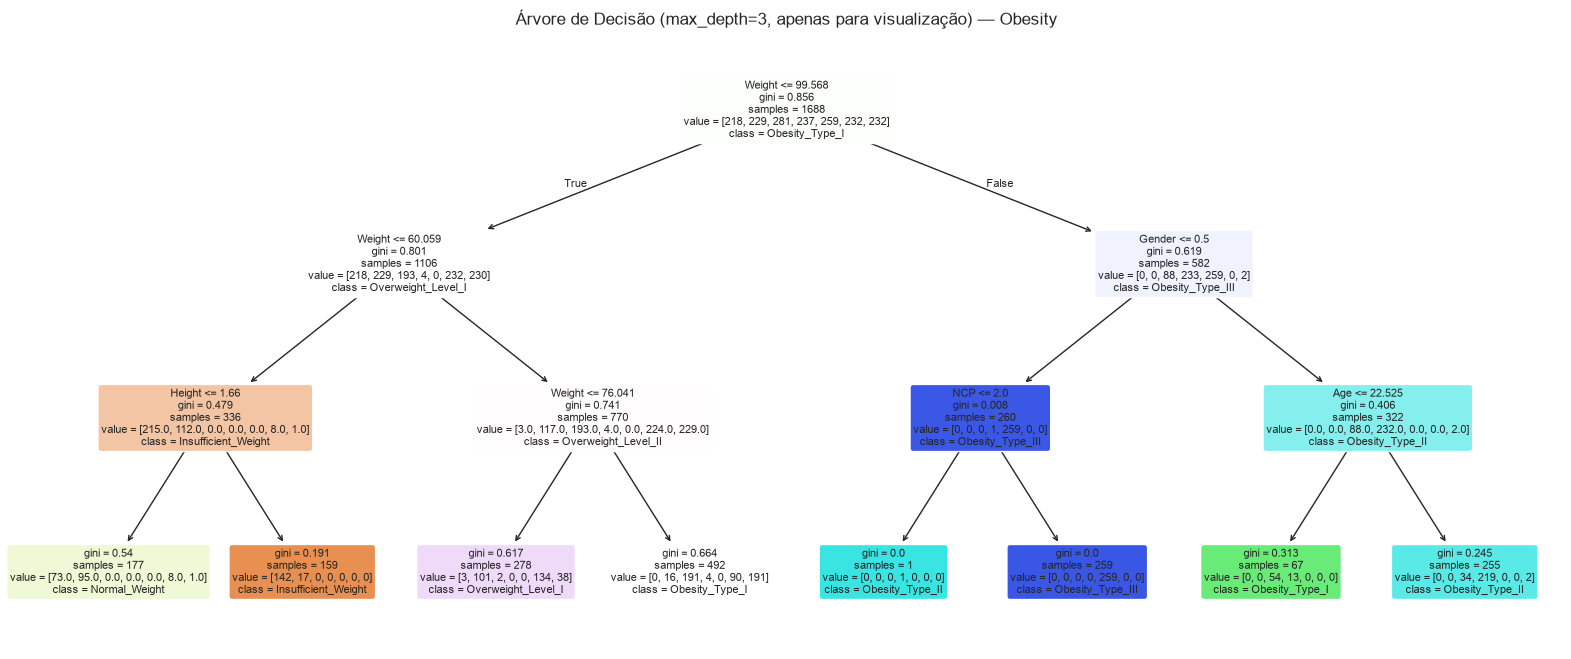

In [18]:
# Visualização simplificada da árvore (profundidade reduzida apenas para leitura visual)
plt.figure(figsize=(20, 8))
plot_tree(DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(X_ob_train, y_ob_train),
          feature_names=X_ob_enc.columns, class_names=y_ob_le.classes_,
          filled=True, rounded=True, fontsize=8)
plt.title('Árvore de Decisão (max_depth=3, apenas para visualização) — Obesity')
plt.show()

Este é apenas um exemplo de como ficaria a árvore de decisão com profundidade máxima de três camadas. Também serve para demonstrar a sua grande interpretabilidade, uma vez que se pode ter um retorno visual de como o modelo funciona.

---
## 3. Dataset 2 — Students Dropout and Academic Success

### 3.1 Descrição do dataset

Dataset com informações acadêmicas, demográficas e socioeconômicas de estudantes de ensino superior
em Portugal, usado para prever a situação acadêmica do aluno. Possui **4424 registros** e **37
colunas** (36 atributos + 1 variável-alvo), sem valores nulos.

**Variável-alvo (`Target`)**: 3 classes — *Dropout* (1421 / 32%), *Graduate* (2209 / 50%), *Enrolled* (794 / 18%) —
com **desbalanceamento moderado** (a classe Enrolled é bem menor que as demais).

**Atributos:** quase todos numéricos/codificados — dados de matrícula (modo de aplicação, curso, nota
de admissão), variáveis socioeconômicas (escolaridade e ocupação dos pais, bolsista, devedor),
desempenho acadêmico no 1º e 2º semestre (unidades curriculares aprovadas, notas) e indicadores
macroeconômicos (taxa de desemprego, inflação, PIB).

In [19]:
dropout = pd.read_csv('StudentsDropout.csv', sep=';', encoding='utf-8-sig')
dropout.columns = [c.strip() for c in dropout.columns]

print("Shape:", dropout.shape)
print("\nValores nulos:", dropout.isnull().sum().sum())
dropout.head()

Shape: (4424, 37)

Valores nulos: 0


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [20]:
dropout.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

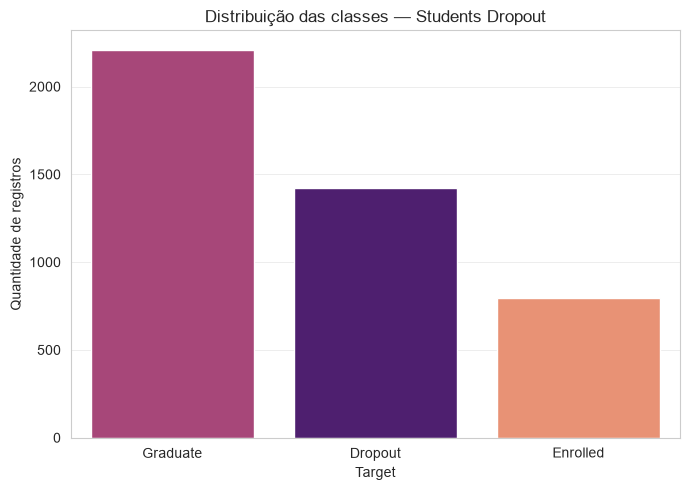

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Proporção:
Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


In [42]:
# Distribuição da variável-alvo
plt.figure(figsize=(7, 5))
order = dropout['Target'].value_counts().index
sns.countplot(data=dropout, x='Target', hue='Target', legend=False, order=order, palette='magma')
plt.title('Distribuição das classes — Students Dropout')
plt.ylabel('Quantidade de registros')
plt.tight_layout()
plt.show()

print(dropout['Target'].value_counts())
print("\nProporção:")
print((dropout['Target'].value_counts(normalize=True) * 100).round(2))

In [22]:
# Estatísticas descritivas (algumas variáveis-chave)
cols_destaque = ['Age at enrollment', 'Admission grade',
                  'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)',
                  'Unemployment rate', 'Inflation rate', 'GDP']
dropout[cols_destaque].describe().T

,count,mean,std,min,25%,50%,75%,max
Age at enrollment,4424.0,23.265145,7.587816,17.00,19.0,20.00,25.00,70.00
Admission grade,4424.0,126.978119,14.482001,95.00,117.9,126.10,134.80,190.00
Curricular units 1st sem (approved),4424.0,4.706600,3.094238,0.00,3.0,5.00,6.00,26.00
Curricular units 2nd sem (approved),4424.0,4.435805,3.014764,0.00,2.0,5.00,6.00,20.00
Unemployment rate,4424.0,11.566139,2.663850,7.60,9.4,11.10,13.90,16.20
Inflation rate,4424.0,1.228029,1.382711,-0.80,0.3,1.40,2.60,3.70
GDP,4424.0,0.001969,2.269935,-4.06,-1.7,0.32,1.79,3.51


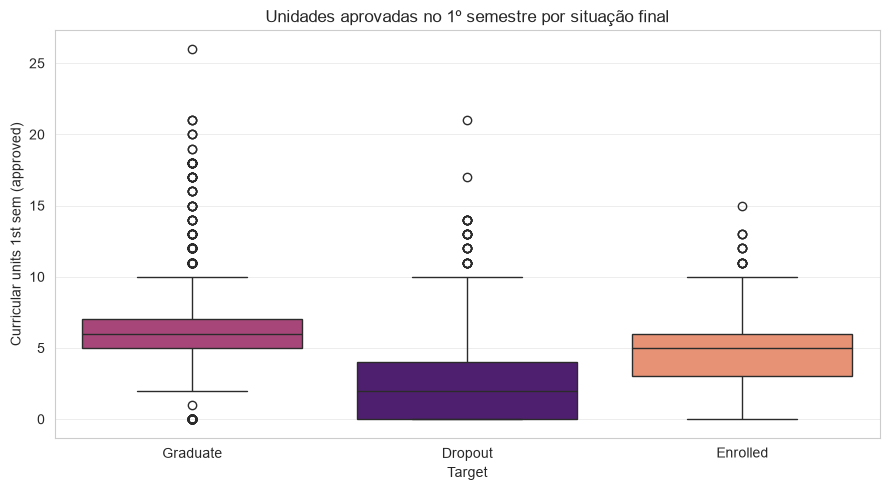

In [44]:
# Relação entre desempenho no 1º semestre e situação final
plt.figure(figsize=(9, 5))
sns.boxplot(data=dropout, x='Target', y='Curricular units 1st sem (approved)', hue='Target', order=order, palette='magma', legend=False)
plt.title('Unidades aprovadas no 1º semestre por situação final')
plt.tight_layout()
plt.show()

Da mesma forma que foi feita na seção dos dados de obesidade, aqui também temos a exploração inicial dos dados, facilitando a visualização de tendências, do desbalanceamento e da dispersão dos dados.

### 3.2 Pré-processamento

A maioria das variáveis já está codificada numericamente na origem do dataset (categorias
representadas por códigos inteiros, conforme dicionário oficial da UCI). Por isso:

- Não é necessário `LabelEncoder` nos atributos (apenas no target).
- Variáveis numéricas padronizadas com `StandardScaler` (importante para a Regressão Logística,
  que é sensível à escala).
- Divisão treino/teste: 80% / 20%, estratificada pela variável-alvo.

In [24]:
target_col = 'Target'
X_dr = dropout.drop(columns=[target_col])
y_dr = dropout[target_col]

y_dr_le = LabelEncoder()
y_dr_enc = y_dr_le.fit_transform(y_dr)
print("Classes (codificadas):", dict(enumerate(y_dr_le.classes_)))

X_dr_train, X_dr_test, y_dr_train, y_dr_test = train_test_split(
    X_dr, y_dr_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_dr_enc
)

scaler_dr = StandardScaler()
X_dr_train_s = scaler_dr.fit_transform(X_dr_train)
X_dr_test_s = scaler_dr.transform(X_dr_test)

print("Treino:", X_dr_train.shape, " Teste:", X_dr_test.shape)

Classes (codificadas): {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}
Treino: (3539, 36)  Teste: (885, 36)


### 3.3 Modelo 1 — Regressão Logística

A Regressão Logística é um modelo linear que estima a probabilidade de pertencimento a cada classe
através de uma combinação linear dos atributos. É interpretável (coeficientes indicam direção e
magnitude do efeito de cada variável sobre a probabilidade de cada classe) e serve como um bom baseline para problemas de classificação. Por ser linear, pode não capturar relações complexas não-lineares entre os atributos.

**Hiperparâmetro testado:** `C` — inverso da força de regularização. Valores menores de `C` aplicam
regularização mais forte (modelo mais simples); valores maiores reduzem a regularização (modelo mais
flexível, mais propenso a overfitting).

In [25]:
resultados_lr = []

for C in [0.01, 1, 100]:
    lr = LogisticRegression(C=C, max_iter=2000, random_state=RANDOM_STATE)
    lr.fit(X_dr_train_s, y_dr_train)

    pred_train = lr.predict(X_dr_train_s)
    pred_test = lr.predict(X_dr_test_s)

    resultados_lr.append({
        'C': C,
        'acc_train': accuracy_score(y_dr_train, pred_train),
        'acc_test': accuracy_score(y_dr_test, pred_test),
        'f1_macro_test': f1_score(y_dr_test, pred_test, average='macro'),
        'precision_macro_test': precision_score(y_dr_test, pred_test, average='macro'),
        'recall_macro_test': recall_score(y_dr_test, pred_test, average='macro'),
    })

df_lr = pd.DataFrame(resultados_lr)
df_lr

,C,acc_train,acc_test,f1_macro_test,precision_macro_test,recall_macro_test
0,0.01,0.771687,0.762712,0.656919,0.698911,0.652024
1,1.00,0.773100,0.768362,0.682601,0.707005,0.675426
2,100.00,0.771969,0.771751,0.688193,0.713010,0.680373


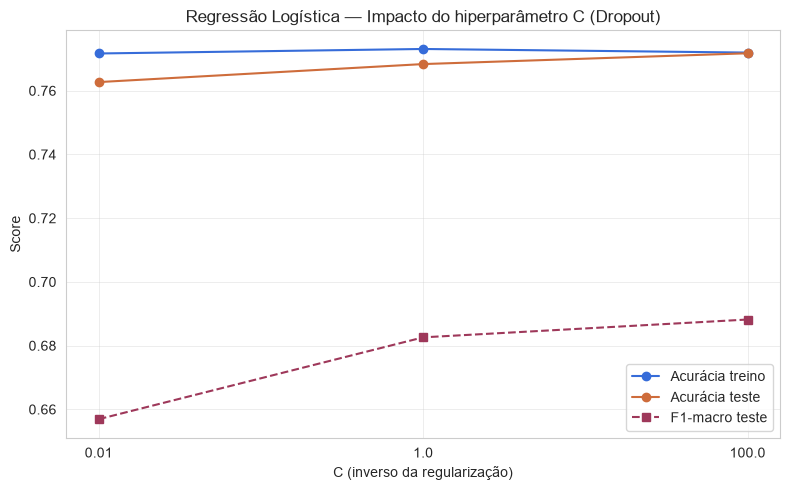

In [26]:
# Gráfico do impacto de C
plt.figure(figsize=(8, 5))
plt.plot(df_lr['C'].astype(str), df_lr['acc_train'], marker='o', label='Acurácia treino')
plt.plot(df_lr['C'].astype(str), df_lr['acc_test'], marker='o', label='Acurácia teste')
plt.plot(df_lr['C'].astype(str), df_lr['f1_macro_test'], marker='s', label='F1-macro teste', linestyle='--')
plt.xlabel('C (inverso da regularização)')
plt.ylabel('Score')
plt.title('Regressão Logística — Impacto do hiperparâmetro C (Dropout)')
plt.legend()
plt.tight_layout()
plt.show()

Pode-se observar que a Regressão Logística é estável neste dataset, ocorrendo pouca variação entre as três configurações do hiperparâmetro C. Isso indica que a estrutura é aproximadamente linear e que o dataset é grande o suficiente para sustentar um modelo com pouca regularização sem overfitting. A falta de grande diferença entre treino e teste em todas as configurações confirma boa generalização. O melhor resultado foi obtido com C=100, uma vez que a menor regularização permitiu que o modelo aproveitasse melhor as relações existentes entre os dados.

In [27]:
# Melhor configuração de Regressão Logística -> usada nas comparações finais
melhor_C = df_lr.loc[df_lr['f1_macro_test'].idxmax(), 'C']
lr_final = LogisticRegression(C=melhor_C, max_iter=2000, random_state=RANDOM_STATE)
lr_final.fit(X_dr_train_s, y_dr_train)
pred_lr_final = lr_final.predict(X_dr_test_s)

print(f"Melhor C: {melhor_C}")
print(classification_report(y_dr_test, pred_lr_final, target_names=y_dr_le.classes_))

Melhor C: 100.0
              precision    recall  f1-score   support

     Dropout       0.79      0.77      0.78       284
    Enrolled       0.54      0.35      0.42       159
    Graduate       0.81      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.69       885
weighted avg       0.75      0.77      0.76       885



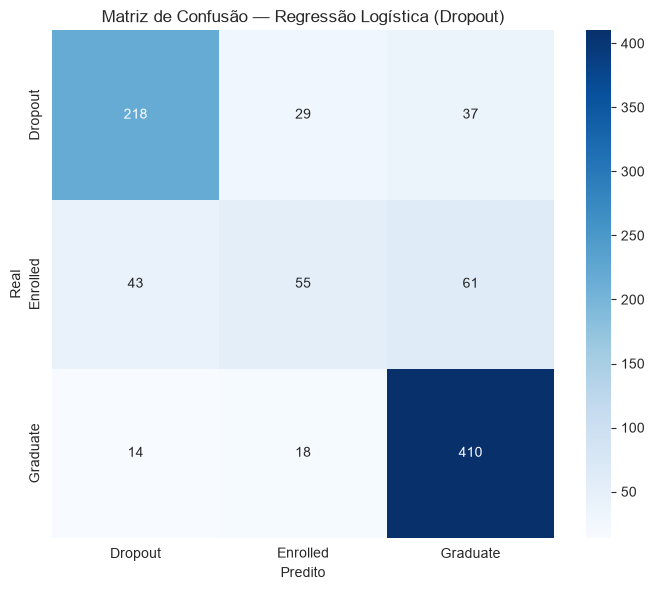

In [28]:
# Matriz de confusão - Regressão Logística
cm_lr = confusion_matrix(y_dr_test, pred_lr_final)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=y_dr_le.classes_, yticklabels=y_dr_le.classes_)
plt.title('Matriz de Confusão — Regressão Logística (Dropout)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

A análise por classe evidencia o desbalanceamento. O Graduate é a classe com maior recall (93%). Dropout tem desempenho intermediário com F1 = 78%. A maior taxa de erros se encontra entre Enrolled e Graduate, sendo aquele o maior problema, com F1 de 42%, classificand a maioria como Graduate. Isso acontece porque Enrolled é a classe mais ambígua (alunos matriculados ainda não mostraram padrão definido de sucesso ou fracasso) e tem o menor número de exemplos de treino, dificultando o aprendizado do modelo. A diferença entre a acurácia e o F1 se dá pelo desequilíbrio dos dados, pois a acurácia é inflada pelos bons resultados em Graduate e Dropout.

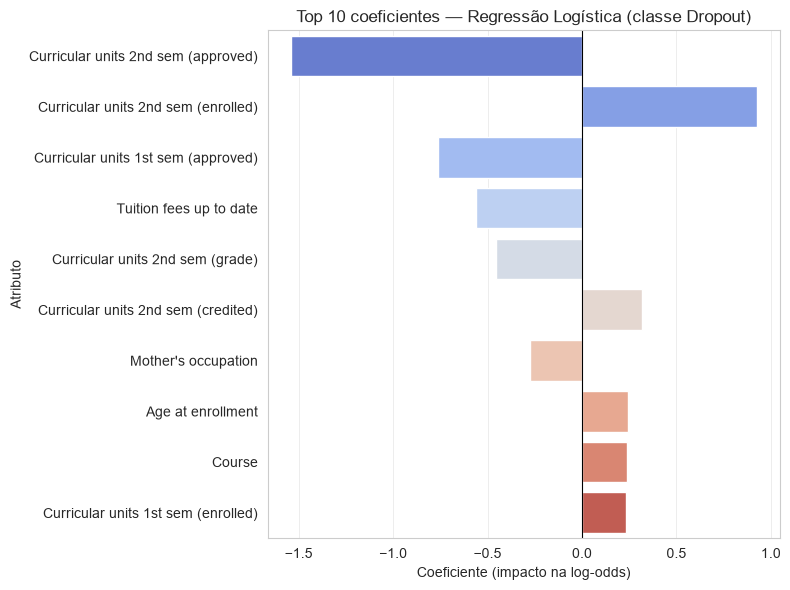

In [45]:
# Interpretabilidade: coeficientes do modelo (para a classe Dropout, por exemplo)
coef_df = pd.DataFrame(lr_final.coef_, columns=X_dr.columns, index=y_dr_le.classes_).T
coef_dropout = coef_df['Dropout'].sort_values(key=abs, ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=coef_dropout.values, y=coef_dropout.index, palette='coolwarm', hue=coef_dropout.index, legend=False)
plt.title('Top 10 coeficientes — Regressão Logística (classe Dropout)')
plt.xlabel('Coeficiente (impacto na log-odds)')
plt.ylabel('Atributo')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

O gráfico de coeficientes é uma vantagem fornecida pelo modelo da Regressão Logística. O coeficiente negativo indica as variáveis que reduzem a probabilidade de Dropout e o positivo indica as que aumentam. Cada unidade a mais aprovada no segundo semestre reduz substancialmente a evasão, enquanto os alunos que se matriculam em muitas disciplinas e não aprovaram têm alto risco de evasão. A adimplência financeira colabora bastante para evitar a evasão e alunos mais velhos na entrada do curso têm um pouco mais de chance de sair do curso. Resumindo, desempenho acadêmico fraco e dificuldade financeiras são os principais preditores de evasão.

### 3.4 Modelo 2 — Árvore de Decisão

Aplicamos novamente a Árvore de Decisão, agora no dataset de evasão escolar, para comparar seu
comportamento em um cenário com mais atributos, mais registros e desbalanceamento de classes. Isso permite avaliar se as conclusões sobre overfitting e generalização do modelo se mantêm em condições diferentes.

**Hiperparâmetro testado:** `min_samples_leaf` — número mínimo de amostras exigido em uma folha.
Valores baixos permitem folhas muito específicas (mais overfitting); valores altos forçam folhas mais
genéricas (mais regularização).

In [30]:
resultados_dt_dr = []

for msl in [1, 10, 50]:
    dt = DecisionTreeClassifier(min_samples_leaf=msl, random_state=RANDOM_STATE)
    dt.fit(X_dr_train, y_dr_train)

    pred_train = dt.predict(X_dr_train)
    pred_test = dt.predict(X_dr_test)

    resultados_dt_dr.append({
        'min_samples_leaf': msl,
        'acc_train': accuracy_score(y_dr_train, pred_train),
        'acc_test': accuracy_score(y_dr_test, pred_test),
        'f1_macro_test': f1_score(y_dr_test, pred_test, average='macro'),
        'precision_macro_test': precision_score(y_dr_test, pred_test, average='macro'),
        'recall_macro_test': recall_score(y_dr_test, pred_test, average='macro'),
    })

df_dt_dr = pd.DataFrame(resultados_dt_dr)
df_dt_dr

,min_samples_leaf,acc_train,acc_test,f1_macro_test,precision_macro_test,recall_macro_test
0,1,1.000000,0.697175,0.638543,0.637794,0.639658
1,10,0.829048,0.711864,0.635950,0.639443,0.634613
2,50,0.768861,0.745763,0.648644,0.686963,0.645998


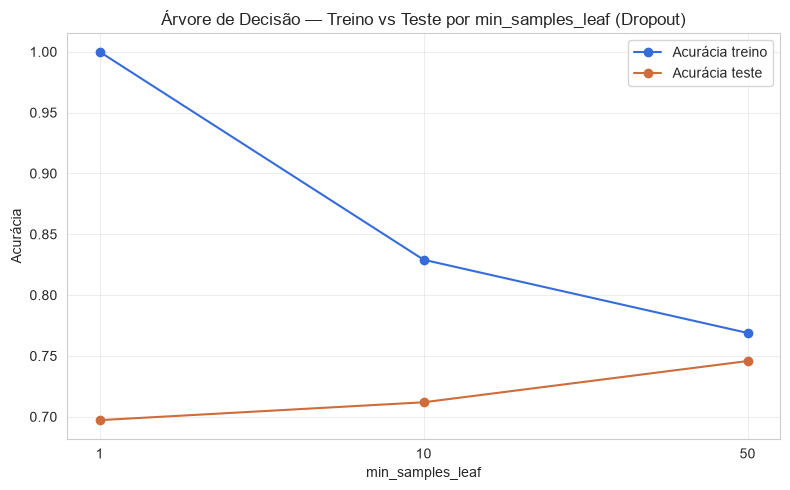

In [31]:
# Gráfico: acurácia treino vs teste por min_samples_leaf (evidencia overfitting)
plt.figure(figsize=(8, 5))
plt.plot(df_dt_dr['min_samples_leaf'].astype(str), df_dt_dr['acc_train'], marker='o', label='Acurácia treino')
plt.plot(df_dt_dr['min_samples_leaf'].astype(str), df_dt_dr['acc_test'], marker='o', label='Acurácia teste')
plt.xlabel('min_samples_leaf')
plt.ylabel('Acurácia')
plt.title('Árvore de Decisão — Treino vs Teste por min_samples_leaf (Dropout)')
plt.legend()
plt.tight_layout()
plt.show()

O gráfico revela muito overfitting com o min_samples_leaf=1, atingindo 100% de acurácia no treino e 69,72% no teste, praticamente memorizando cada exemplo de treino sem aprender padrões generalizáveis. Com min_samples_leaf=10, o overfitting cai, tendo o treino em 82,90% e o teste em 71,19%. Com min_samples_leaf=50 o treino e o teste ficam bem mais próximos, 76,89% e 74,58%, respectivamente, indicando melhor generalização. Isso ocorre pois o dataset de Dropout tem mais ruído e relações mais complexas que o de obesidade, o que o torma mais propenso a overfitting em árvores sem restrição.

In [32]:
# Melhor configuração de Árvore -> usada nas comparações finais
melhor_msl = df_dt_dr.loc[df_dt_dr['f1_macro_test'].idxmax(), 'min_samples_leaf']
dt_final_dr = DecisionTreeClassifier(min_samples_leaf=int(melhor_msl), random_state=RANDOM_STATE)
dt_final_dr.fit(X_dr_train, y_dr_train)
pred_dt_final_dr = dt_final_dr.predict(X_dr_test)

print(f"Melhor min_samples_leaf: {melhor_msl}")
print(classification_report(y_dr_test, pred_dt_final_dr, target_names=y_dr_le.classes_))

Melhor min_samples_leaf: 50
              precision    recall  f1-score   support

     Dropout       0.73      0.77      0.75       284
    Enrolled       0.55      0.26      0.36       159
    Graduate       0.79      0.90      0.84       442

    accuracy                           0.75       885
   macro avg       0.69      0.65      0.65       885
weighted avg       0.72      0.75      0.72       885



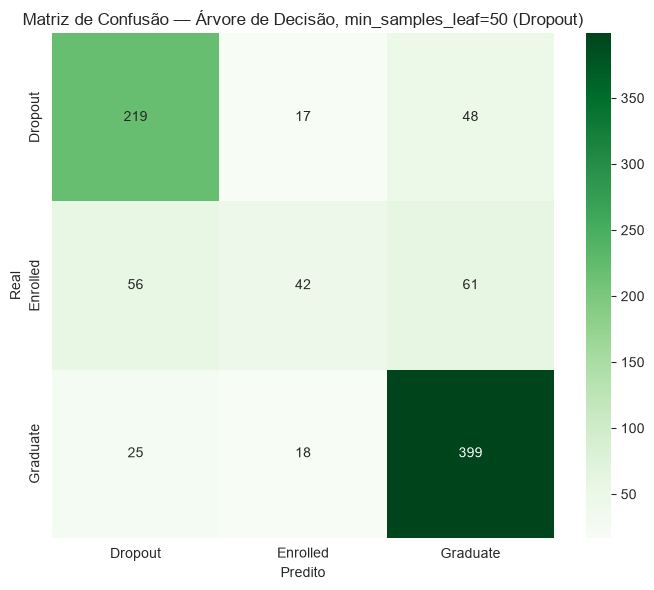

In [33]:
# Matriz de confusão - Árvore de Decisão (Dropout)
cm_dt_dr = confusion_matrix(y_dr_test, pred_dt_final_dr)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_dt_dr, annot=True, fmt='d', cmap='Greens',
            xticklabels=y_dr_le.classes_, yticklabels=y_dr_le.classes_)
plt.title(f'Matriz de Confusão — Árvore de Decisão, min_samples_leaf={melhor_msl} (Dropout)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

Os resultados por classe da Árvore de Decisão são levemente inferiores aos da Regressão Logística no detaset de Dropout. A classe Enrolled continua sendo a mais problemática, saindo de F1 = 42% para F1 = 36%, e os erros da classe Dropout aumentaram, de 37 erros para 48. Isso sugere que, para este problema específico, as relações entre os atributos e a variável-alvo são aproximadamente lineares, favorecendo a Regressão Logística. A Árvore de Decisão, mesmo sendo um modelo mais flexível, sofre mais com o ruído e o desbalanceamento de classes sem técnicas de compensação.

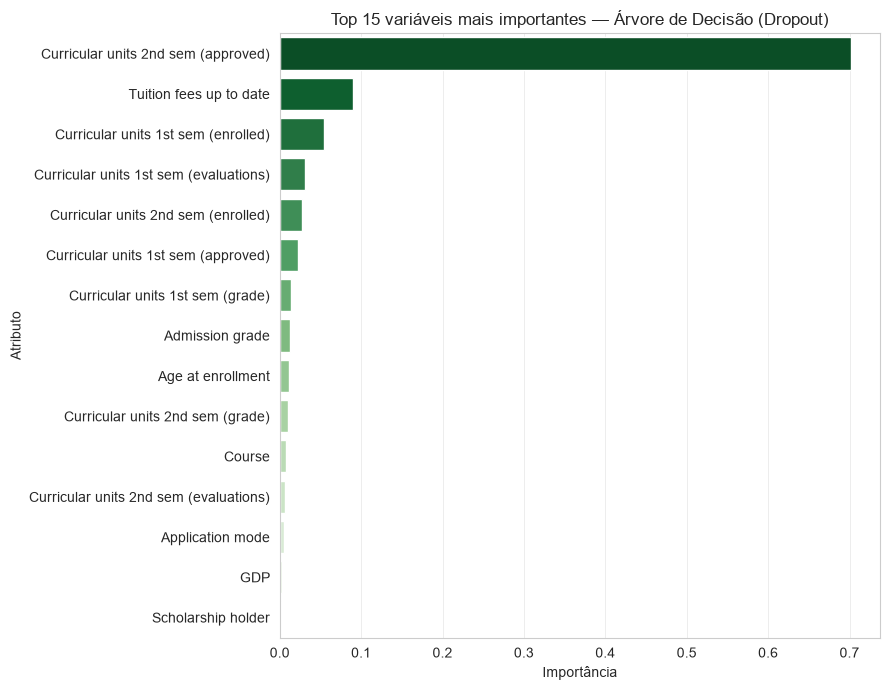

In [46]:
# Importância das variáveis (interpretabilidade)
importancias_dr = pd.Series(dt_final_dr.feature_importances_, index=X_dr.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=importancias_dr.values, y=importancias_dr.index, palette='Greens_r', hue=importancias_dr.index, legend=False)
plt.title('Top 15 variáveis mais importantes — Árvore de Decisão (Dropout)')
plt.ylabel('Atributo')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

O gráfico de importância das variáveis mostra que 'Curricular units 2nd sem (approved)' domina o modelo com 70,2% de importância, carregando maior parte do poder preditivo. o 'Tuition fees up to date' aparece em segundo dom 9% e 'Curricular units 1st sem (enrolled) com 5,4%. Esse resultado é coerente com os coeficientes da Regressão Logística. A concentração de importância em poucas variáveis pode ser um sinal de que o modelo está utilizando atalhos muito diretos para classificar, funcionando bem em casos mais claros e falhando em casos mais ambíguos, como na classe Enrolled.

---
## 4. Comparação entre os 4 modelos

Resumo consolidado com a melhor configuração de cada modelo em cada dataset.

In [35]:
comparacao = pd.DataFrame([
    {
        'Dataset': 'Obesity',
        'Modelo': 'Naive Bayes',
        'Hiperparâmetro': f'var_smoothing={melhor_vs}',
        'Acurácia': accuracy_score(y_ob_test, pred_nb_final),
        'F1-macro': f1_score(y_ob_test, pred_nb_final, average='macro'),
        'Precisão-macro': precision_score(y_ob_test, pred_nb_final, average='macro'),
        'Recall-macro': recall_score(y_ob_test, pred_nb_final, average='macro'),
    },
    {
        'Dataset': 'Obesity',
        'Modelo': 'Árvore de Decisão',
        'Hiperparâmetro': f'max_depth={melhor_depth}',
        'Acurácia': accuracy_score(y_ob_test, pred_dt_final_ob),
        'F1-macro': f1_score(y_ob_test, pred_dt_final_ob, average='macro'),
        'Precisão-macro': precision_score(y_ob_test, pred_dt_final_ob, average='macro'),
        'Recall-macro': recall_score(y_ob_test, pred_dt_final_ob, average='macro'),
    },
    {
        'Dataset': 'Dropout',
        'Modelo': 'Regressão Logística',
        'Hiperparâmetro': f'C={melhor_C}',
        'Acurácia': accuracy_score(y_dr_test, pred_lr_final),
        'F1-macro': f1_score(y_dr_test, pred_lr_final, average='macro'),
        'Precisão-macro': precision_score(y_dr_test, pred_lr_final, average='macro'),
        'Recall-macro': recall_score(y_dr_test, pred_lr_final, average='macro'),
    },
    {
        'Dataset': 'Dropout',
        'Modelo': 'Árvore de Decisão',
        'Hiperparâmetro': f'min_samples_leaf={melhor_msl}',
        'Acurácia': accuracy_score(y_dr_test, pred_dt_final_dr),
        'F1-macro': f1_score(y_dr_test, pred_dt_final_dr, average='macro'),
        'Precisão-macro': precision_score(y_dr_test, pred_dt_final_dr, average='macro'),
        'Recall-macro': recall_score(y_dr_test, pred_dt_final_dr, average='macro'),
    },
])

comparacao_display = comparacao.copy()
for col in ['Acurácia', 'F1-macro', 'Precisão-macro', 'Recall-macro']:
    comparacao_display[col] = comparacao_display[col].round(4)

comparacao_display

,Dataset,Modelo,Hiperparâmetro,Acurácia,F1-macro,Precisão-macro,Recall-macro
0,Obesity,Naive Bayes,var_smoothing=0.01,0.6123,0.5888,0.6604,0.6064
1,Obesity,Árvore de Decisão,max_depth=7,0.8629,0.8607,0.8672,0.8579
2,Dropout,Regressão Logística,C=100.0,0.7718,0.6882,0.7130,0.6804
3,Dropout,Árvore de Decisão,min_samples_leaf=50,0.7458,0.6486,0.6870,0.6460


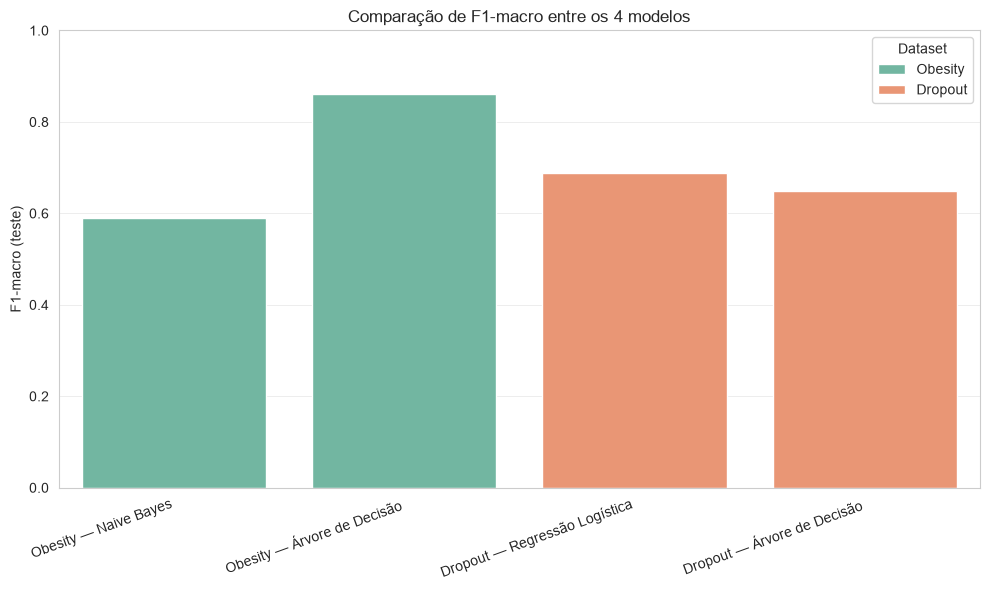

In [36]:
# Gráfico comparativo de F1-macro entre os 4 modelos
plt.figure(figsize=(10, 6))
comparacao['Modelo_Dataset'] = comparacao['Dataset'] + ' — ' + comparacao['Modelo']
sns.barplot(data=comparacao, x='Modelo_Dataset', y='F1-macro', hue='Dataset', dodge=False, palette='Set2')
plt.title('Comparação de F1-macro entre os 4 modelos')
plt.ylabel('F1-macro (teste)')
plt.xlabel('')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

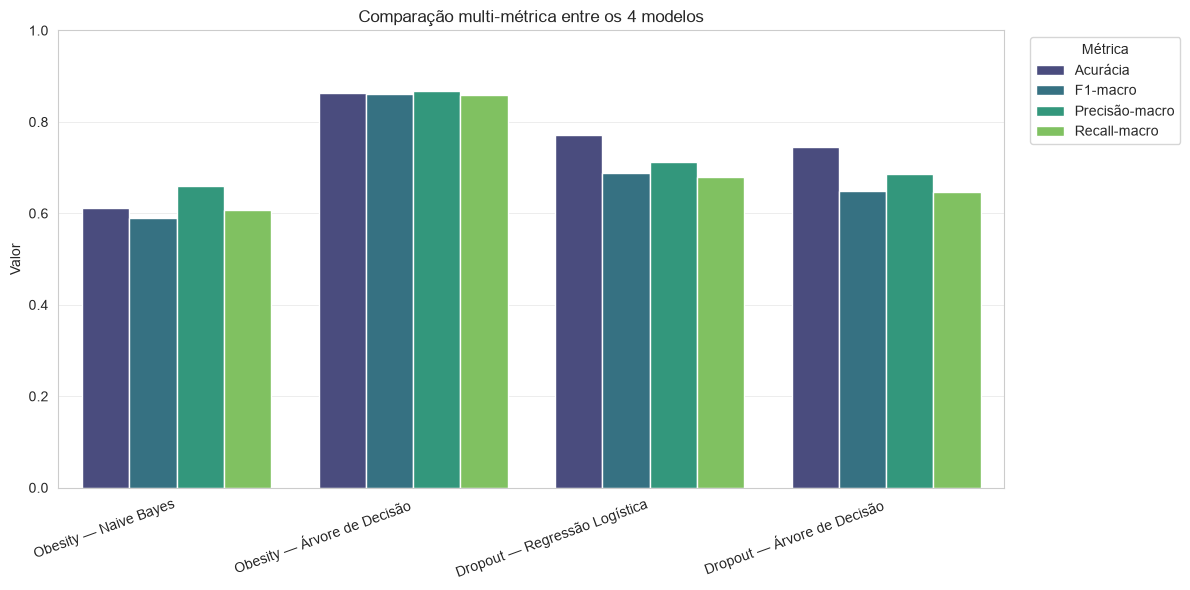

In [37]:
# Gráfico comparativo com múltiplas métricas
metricas_plot = comparacao.melt(
    id_vars=['Modelo_Dataset'],
    value_vars=['Acurácia', 'F1-macro', 'Precisão-macro', 'Recall-macro'],
    var_name='Métrica', value_name='Valor'
)

plt.figure(figsize=(12, 6))
sns.barplot(data=metricas_plot, x='Modelo_Dataset', y='Valor', hue='Métrica', palette='viridis')
plt.title('Comparação multi-métrica entre os 4 modelos')
plt.ylabel('Valor')
plt.xlabel('')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
plt.legend(title='Métrica', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Vale destacar duas comparações:
- **Obesity**: a Árvore de decisão supera o Naive Bayes, 86,29% vs. 61,23% em acurácia e 86,07% vs. 58,88% em F1. Essa diferença indica que as classes de obesidade têm fronteiras não-lineares e correlações entre atributos que o Naive Bayes não consegue identificar pela suposição de independência. A Árvore de Decisão, ao criar partições baseadas em peso e altura, captura diretamente as relações mais relevantes do dataset.
- **Dropout**: a Regressão Logística supera a Árvore de Decisão, 77,18% vs. 74,58% em acurácia e 68,82% vs. 64,86% em F1. A diferença é menor, mas consistente em todas as métricas. Isso sugere que as relações entre os preditores e a evasão são suficientemente lineares para que a Regressão Logística seja competitiva e que a capacidade adicional de avaliar não-linearidades da Árvore de Decisão não compensa o overfitting mais difícil de controlar nesse dataset.

Pode-se observar que os dois modelos comparados dentro de cada dataset têm naturezas muito diferentes: Naive Bayes e Regressão Logística são modelos de baixa complexidade com poucos parâmetros livres. A Árvore de Decisão é um modelo de alta flexibilidade que depende bastante da escolha adequada de hiperparâmetros para ter boa generalização. Nos resultados obtidos, o modelo da Árvore de Decisão se beneficiou mais de dados não-lineares do que quando eles possuíam mais ruído e maior desbalanceamento.

---
## 5. Discussão Crítica

### 5.1 Overfitting e Underfitting

**Obesity — Árvore de Decisão:** o experimento com `max_depth` evidencia a transição
de underfitting para overfitting. Com `max_depth=3`, o modelo é simples demais e erra tanto no treino
quanto no teste (underfitting). Conforme a profundidade aumenta (`max_depth=7` e, principalmente,
`max_depth=None`), a acurácia de treino se aproxima de 100%, enquanto a de teste cresce em ritmo menor
— um sinal de overfitting quando a árvore cresce sem limite.

**Dropout — Árvore de Decisão:** o mesmo padrão aparece com `min_samples_leaf`. Com `min_samples_leaf=1`,
a árvore memoriza o conjunto de treino (acurácia de treino próxima de 100%), mas perde desempenho no
teste. Aumentar `min_samples_leaf` funciona como uma forma de regularização, reduzindo a complexidade
da árvore e aproximando o desempenho de treino e teste.

**Naive Bayes e Regressão Logística:** por serem modelos mais simples e com menos graus de liberdade,
ambos apresentam diferenças pequenas entre acurácia de treino e teste em todas as variações testadas,
ou seja, generalizam de forma mais estável, embora com desempenho absoluto possivelmente inferior ao
da melhor árvore.

### 5.2 Generalização

A capacidade de generalização, desempenho em dados nunca vistos, foi avaliada apenas na base de teste, visto que não se avalia isso na base de treino. Os resultados sugerem que, para o dataset Obesity, a Árvore de Decisão com
profundidade moderada generaliza bem e supera o Naive Bayes, provavelmente porque os atributos têm
relações não-lineares com o nível de obesidade que a suposição de independência condicional do Naive
Bayes não captura. Já no dataset Dropout, a diferença entre Regressão Logística e Árvore de Decisão é
mais sutil, e a Regressão Logística se mostra competitiva, possivelmente porque várias relações entre
desempenho acadêmico e evasão são aproximadamente lineares.

### 5.3 Interpretabilidade

- **Naive Bayes:** pouco interpretável em termos de peso de variáveis, já que opera sobre
  distribuições de probabilidade por classe, mas é totalmente transparente quanto ao seu funcionamento
  matemático.
- **Regressão Logística:** alta interpretabilidade — os coeficientes indicam a direção (positiva ou
  negativa) e a magnitude do efeito de cada variável sobre a probabilidade de cada classe.
- **Árvore de Decisão:** alta interpretabilidade visual (é possível seguir o caminho de decisão) e
  fornece `feature_importances_`, que ajudam a identificar quais variáveis mais contribuem para a
  separação das classes — por exemplo, peso e altura no caso do Obesity, e desempenho no 1º/2º semestre
  no caso do Dropout.

### 5.4 Efeito do desbalanceamento de classes (Dropout)

Diferente do Obesity (classes balanceadas), o Dropout tem desbalanceamento moderado (a classe
*Enrolled* é minoritária). Isso explica por que a acurácia geral tende a ser mais alta que o F1-macro
nesse dataset: a acurácia é "inflada" pelo bom desempenho nas classes majoritárias (*Graduate* e
*Dropout*), enquanto o F1 penaliza mais o desempenho fraco na classe minoritária. Por isso, o
F1 é uma métrica mais confiável aqui do que a acurácia simples.

---
## 6. Conclusão

Este trabalho permitiu explorar de forma prática e comparativa o comportamento de três algoritmos de classificação supervisionada em dois problemas diferentes. 

No dataset de obesidade, a Árvore de Decisão apresentou desempenho superior ao Naive Bayes, com F1 de 86,07% contra 58,88%, pois conseguiu capturar melhor relações não-lineares e correlações entre atributos como peso e altura. No dataset de evasão acadêmica, a Regressão Logística superou a Árvore de Decisão, com F1 de 68,82% contra 64,86%, indicando que, nesse caso, um modelo linear simples conseguiu generalizar melhor diante de dados desbalanceados.

A seguir serão apresentados os principais aprendizados e as limitações do trabalho.

**Principais aprendizados:**
- A escolha do modelo deve considerar a natureza dos dados para obtermos os melhores resultados.
- Hiperparâmetros têm um impacto direto no equilíbrio entre overfitting e underfitting.
- F1 é uma métrica mais confiável que acurácia em problemas desbalanceados.
- Modelos simples e interpretáveis não necessariamente perdem para modelos mais complexos, depende do problema.

**Limitações do trabalho:**
- O pré-processamento utilizado é relativamente simples (Label Encoding em vez de One-Hot Encoding
  para variáveis categóricas nominais no dataset Obesity), o que pode introduzir uma falsa noção de
  ordinalidade entre categorias sem ordem natural.
- Não foi realizada validação cruzada (apenas um split treino/teste único), o que pode tornar as
  métricas mais sensíveis à aleatoriedade da divisão dos dados.
- A busca de hiperparâmetros foi manual e limitada a 3 valores por modelo, podendo não representar a
  configuração ótima de cada algoritmo.